# FMCG Retail Sales & Consumer Behavior Analysis
**Target Category:** Health & Beauty

## Summary
**Objective:** Analyze retail supermarket transaction data to uncover purchasing patterns, optimize supply chain timing, and segment customers using Machine Learning.

**Top 3 Business Insights:**
1. **Supply Chain Optimization:** Health & Beauty sales experience a massive volume spike on Saturdays at 1:00 PM ($2,087 in a single hour). High-velocity items (toothpaste, soaps) must be fully restocked by Saturday morning to prevent stockouts.
2. **Geographic Upsell Opportunity:** Overall, Loyalty Members drive 71% more revenue. However, in the Giza branch, *non-members* actually have a higher Average Order Value ($327 vs $314). We should partner with the retailer to launch a targeted loyalty-acquisition campaign at Giza.
3. **Retention Risk (Predictive Segmentation):** A K-Means clustering model revealed a critical "Premium Cart Loaders" persona. They spend the most per trip (Avg: $697) but report mediocre satisfaction (6.5/10). Recommending bulk-buy SKUs or premium checkout lanes to prevent churn among these high-value buyers.
---

# 1. Data Preparation & Cleaning

---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("SuperMarket Analysis.csv")

# Check for null values
print("--- Null Values ---")
print(df.isnull().sum())

# Convert Date and Time to datetime formats
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time'])

# Extract Hour and Day of the week
df['Hour'] = df['Time'].dt.hour
df['Day of the week'] = df['Date'].dt.day_name()

--- Null Values ---
Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64


/var/folders/dp/hrzpy61d7fj767t2tgp22ld40000gn/T/ipykernel_27908/503036959.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'])


# 2. Exploratory Data Analysis (EDA)

---

In [4]:
product_perf = df.groupby('Product line')[['Sales', 'gross income']].sum().sort_values(by='Sales', ascending=False)
print("\n--- Product Line Performance ---")
print(product_perf)

# Health & Beauty Deep Dive
hb_df = df[df['Product line'] == 'Health and beauty']

print("\n--- H&B Sales by Gender ---")
print(hb_df.groupby('Gender')['Sales'].sum())

print("\n--- H&B Sales by Customer Type ---")
print(hb_df.groupby('Customer type')['Sales'].sum())

# Branch Segmentation for Health & Beauty
hb_branch = hb_df.groupby(['Branch', 'Customer type']).agg(
    AOV=('Sales', 'mean'),
    Total_Gross_Income=('gross income', 'sum')
).reset_index()
print("\n--- Branch Segmentation (AOV & Gross Income) ---")
print(hb_branch)

# Time-of-Day Heatmap
pivot = hb_df.pivot_table(index='Hour', columns='Day of the week', values='Sales', aggfunc='sum', fill_value=0)
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = pivot.reindex(columns=[d for d in days_order if d in pivot.columns])


--- Product Line Performance ---
                             Sales  gross income
Product line                                    
Food and beverages      56144.8440     2673.5640
Sports and travel       55122.8265     2624.8965
Electronic accessories  54337.5315     2587.5015
Fashion accessories     54305.8950     2585.9950
Home and lifestyle      53861.9130     2564.8530
Health and beauty       49193.7390     2342.5590

--- H&B Sales by Gender ---
Gender
Female    23418.7275
Male      25775.0115
Name: Sales, dtype: float64

--- H&B Sales by Customer Type ---
Customer type
Member    31036.824
Normal    18156.915
Name: Sales, dtype: float64

--- Branch Segmentation (AOV & Gross Income) ---
  Branch Customer type         AOV  Total_Gross_Income
0   Alex        Member  322.271250            399.0025
1   Alex        Normal  200.890500            200.8905
2  Cairo        Member  441.190050            630.2715
3  Cairo        Normal  293.259065            321.1885
4   Giza        Member  3

# 3. Temporal Analysis (Heatmap)

---

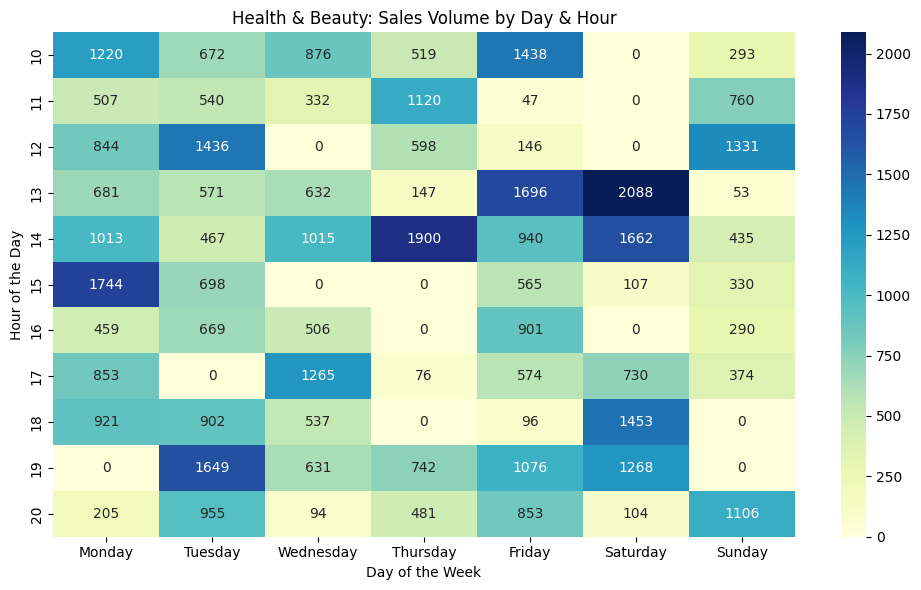

In [15]:
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, cmap='YlGnBu', annot=True, fmt=".0f")
plt.title('Health & Beauty: Sales Volume by Day & Hour')
plt.ylabel('Hour of the Day')
plt.xlabel('Day of the Week')
plt.tight_layout()
plt.show()

# 4. Customer Segmentation

---


--- K-Means Cluster Summary ---
   Cluster   Avg_Spend  Avg_Rating  Customer_Count
0        0  236.745283    8.657682             371
1        1  195.120670    5.675062             405
2        2  696.921328    6.528125             224


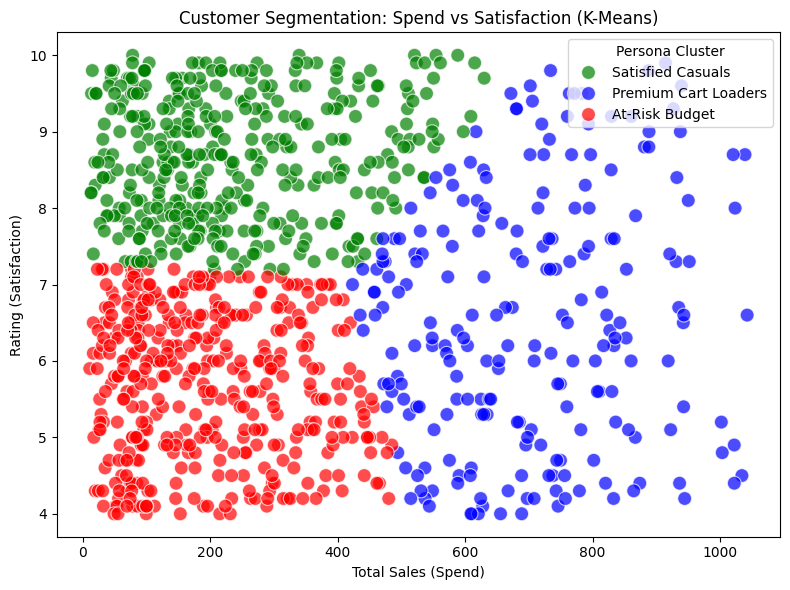

In [ ]:
# Isolate 'Total' (Mapped to 'Sales' in this dataset) and 'Rating'
features = df[['Sales', 'Rating']]

# Scale the data for accurate clustering
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Apply K-Means (3 Clusters)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(features_scaled)

# Analyze the Clusters
cluster_summary = df.groupby('Cluster').agg(
    Avg_Spend=('Sales', 'mean'),
    Avg_Rating=('Rating', 'mean'),
    Customer_Count=('Sales', 'count')
).reset_index()
print("\n--- K-Means Cluster Summary ---")
print(cluster_summary)

# Visualize Clusters
persona_mapping = {
    0: 'Satisfied Casuals',
    1: 'At-Risk Budget',
    2: 'Premium Cart Loaders'
}
df['Persona'] = df['Cluster'].map(persona_mapping)

custom_palette = {
    'Satisfied Casuals': 'green',       
    'At-Risk Budget': 'red',
    'Premium Cart Loaders': 'blue'
}

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, 
    x='Sales', 
    y='Rating', 
    hue='Persona', 
    palette=custom_palette,
    s=100, 
    alpha=0.7
)

plt.title('Customer Segmentation: Spend vs Satisfaction (K-Means)')
plt.xlabel('Total Sales (Spend)')
plt.ylabel('Rating (Satisfaction)')
plt.legend(title='Persona Cluster')
plt.tight_layout()
plt.show()